Accuracy: 87.50%



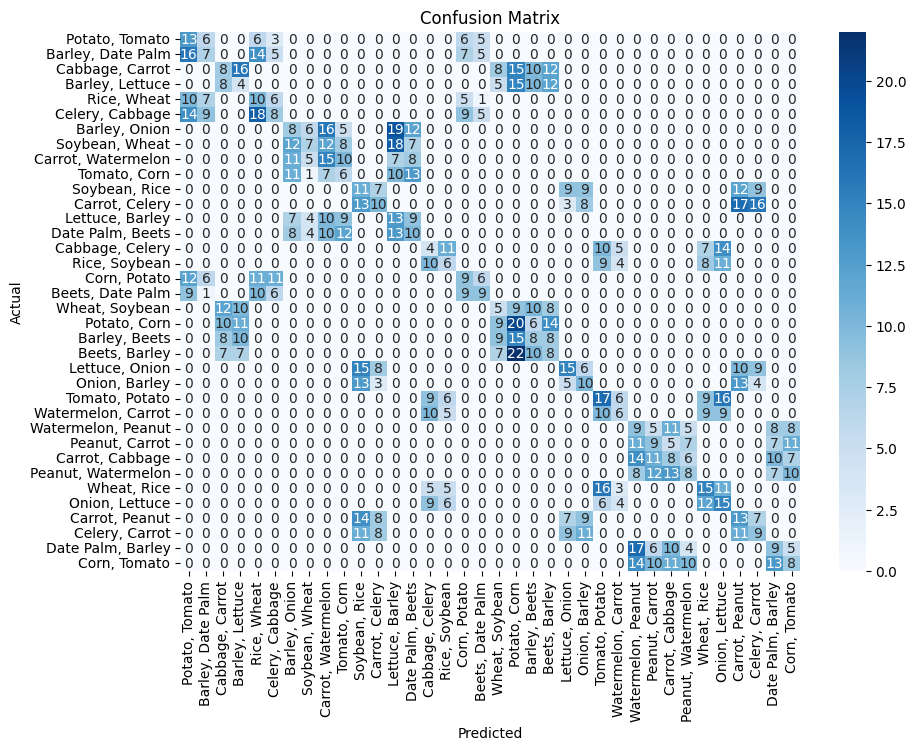

In [7]:

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
dataset_path = "/content/soil_suitability_dataset.csv"  # Change path if stored elsewhere
df = pd.read_csv(dataset_path)

# Display first few rows
df.head()

# Convert categorical data into numerical (One-Hot Encoding)
df_encoded = pd.get_dummies(df, columns=["Soil Type", "pH Level", "Drainage Capacity"])

# Define feature set (X) and target variable (y)
X = df_encoded.drop(columns=["Recommended Crops"])  # Drop target column
y = df["Recommended Crops"]  # Target variable

# Convert target variable into classification labels
y = y.astype('category').cat.codes

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*5* 100:.2f}%\n")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=df["Recommended Crops"].unique(), yticklabels=df["Recommended Crops"].unique())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
